In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Consistent visual style across all plots ──────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
ACCENT = "#2563EB"   # primary colour used throughout
GRAY   = "#94A3B8"   # secondary / muted colour

# ── Load the cleaned dataset ───────────────────────────────────────────────────
clean_df = pd.read_parquet("yellow_tripdata_2025-11_clean.parquet")

# ── Recreate the analytical layers from the cleaning notebook ─────────────────
# Layer 1: all vendors — use for demand, revenue, time patterns
layer1_df = clean_df.copy()

# Layer 2: vendors 1 & 2 with full schema — use for passenger/rate analysis
layer2_df = clean_df[
    clean_df["VendorID"].isin([1, 2])
].dropna(subset=["passenger_count", "RatecodeID", "congestion_surcharge", "Airport_fee"]).copy()

# Revenue layer: exclude refunds/adjustments
revenue_df = clean_df[~clean_df["is_refund_or_adjustment"]].copy()

print(f"Layer 1 (all vendors):          {len(layer1_df):>10,.0f} rows")
print(f"Layer 2 (extended schema):      {len(layer2_df):>10,.0f} rows")
print(f"Revenue layer (no refunds):     {len(revenue_df):>10,.0f} rows")

Layer 1 (all vendors):           3,989,123 rows
Layer 2 (extended schema):       3,060,295 rows
Revenue layer (no refunds):      3,874,008 rows


## When and where is demand highest?

In [2]:
# ── Extract time features ──────────────────────────────────────────────────────
# We create these on layer1_df since we need them for demand analysis.
# .dt accessor lets us pull calendar components out of a datetime column.

layer1_df = layer1_df.copy()  # avoid SettingWithCopyWarning
layer1_df["hour"]        = layer1_df["tpep_pickup_datetime"].dt.hour
layer1_df["day_of_week"] = layer1_df["tpep_pickup_datetime"].dt.day_name()
layer1_df["day_num"]     = layer1_df["tpep_pickup_datetime"].dt.dayofweek  # 0=Mon
layer1_df["week"]        = layer1_df["tpep_pickup_datetime"].dt.isocalendar().week.astype(int)

# Ordered list for consistent axis labels
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

print("Time features added.")
layer1_df[["tpep_pickup_datetime", "hour", "day_of_week", "week"]].head(3)

Time features added.


,tpep_pickup_datetime,hour,day_of_week,week
0,2025-11-01 00:49:07,0,Saturday,44
1,2025-11-01 00:07:19,0,Saturday,44
2,2025-11-01 00:00:00,0,Saturday,44


In [3]:
hourly = layer1_df.groupby("hour").size().reset_index(name='trips')

In [4]:
hourly.head(5)

,hour,trips
0,0,129479
1,1,90062
2,2,59691
3,3,43649
4,4,35778


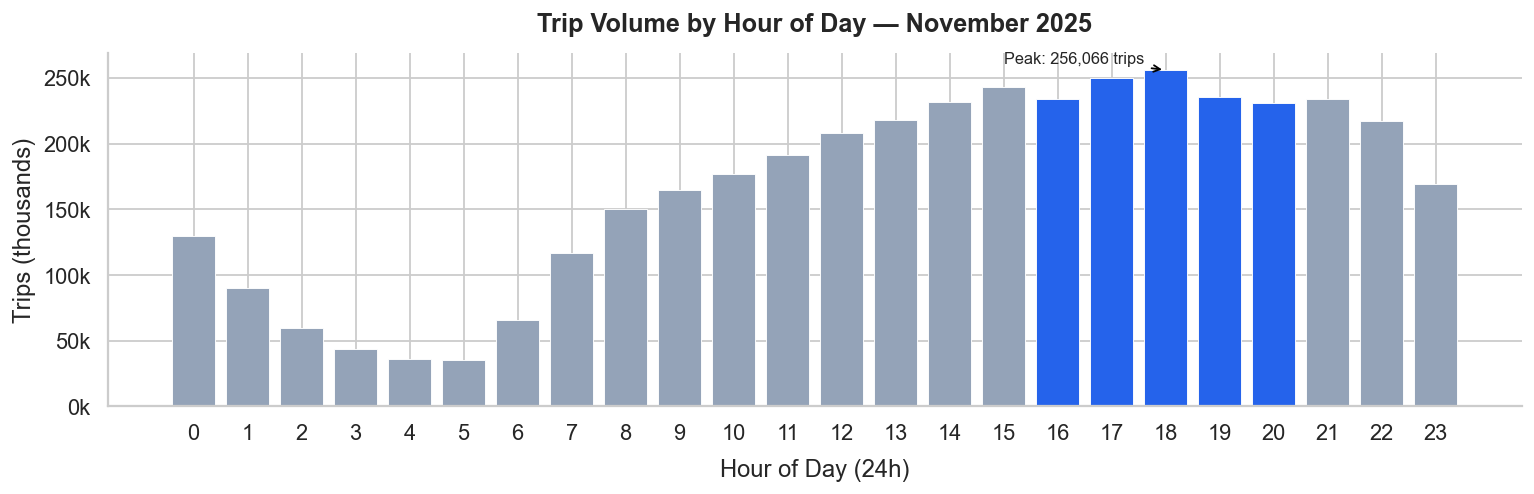

In [5]:
fig , ax = plt.subplots(figsize=(12,4))

bars= ax.bar(hourly['hour'],hourly['trips']/1000,color=[ACCENT if h in range(16, 21) else GRAY for h in hourly["hour"]],
              edgecolor="white", linewidth=0.5)

ax.set_xlabel("Hour of Day (24h)", labelpad=8)
ax.set_ylabel("Trips (thousands)")
ax.set_title("Trip Volume by Hour of Day — November 2025", fontsize=14, fontweight="bold", pad=12)
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))

peak_hour = hourly.loc[hourly["trips"].idxmax()]
ax.annotate(f"Peak: {int(peak_hour['trips']):,} trips",
            xy=(peak_hour["hour"], peak_hour["trips"] / 1_000),
            xytext=(peak_hour["hour"] - 3, peak_hour["trips"] / 1_000 + 5),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9)

plt.tight_layout()
# plt.savefig("plots/01_hourly_demand.png", bbox_inches="tight")
plt.show()


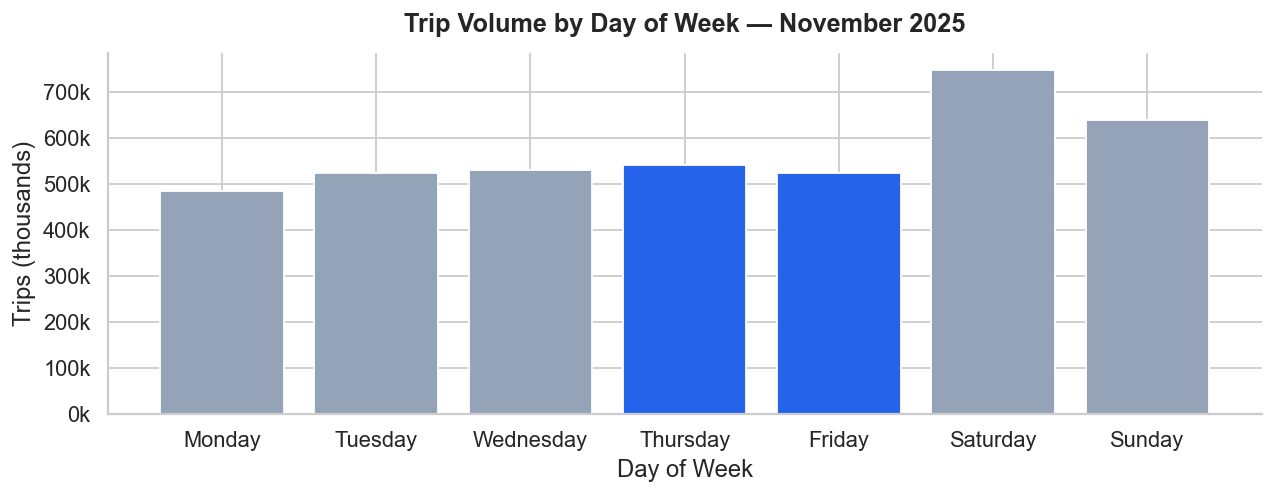

In [6]:
# ── Plot 2: Day-of-week trip volume ────────────────────────────────────────────

dow = (
    layer1_df.groupby(["day_num", "day_of_week"])
    .size()
    .reset_index(name="trips")
    .sort_values("day_num")
)

fig, ax = plt.subplots(figsize=(10, 4))

colors = [ACCENT if d in ["Friday", "Thursday"] else GRAY for d in dow["day_of_week"]]
ax.bar(dow["day_of_week"], dow["trips"] / 1_000, color=colors, edgecolor="white")

ax.set_xlabel("Day of Week")
ax.set_ylabel("Trips (thousands)")
ax.set_title("Trip Volume by Day of Week — November 2025", fontsize=14, fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))

plt.tight_layout()
# plt.savefig("plots/02_dow_demand.png", bbox_inches="tight")
plt.show()

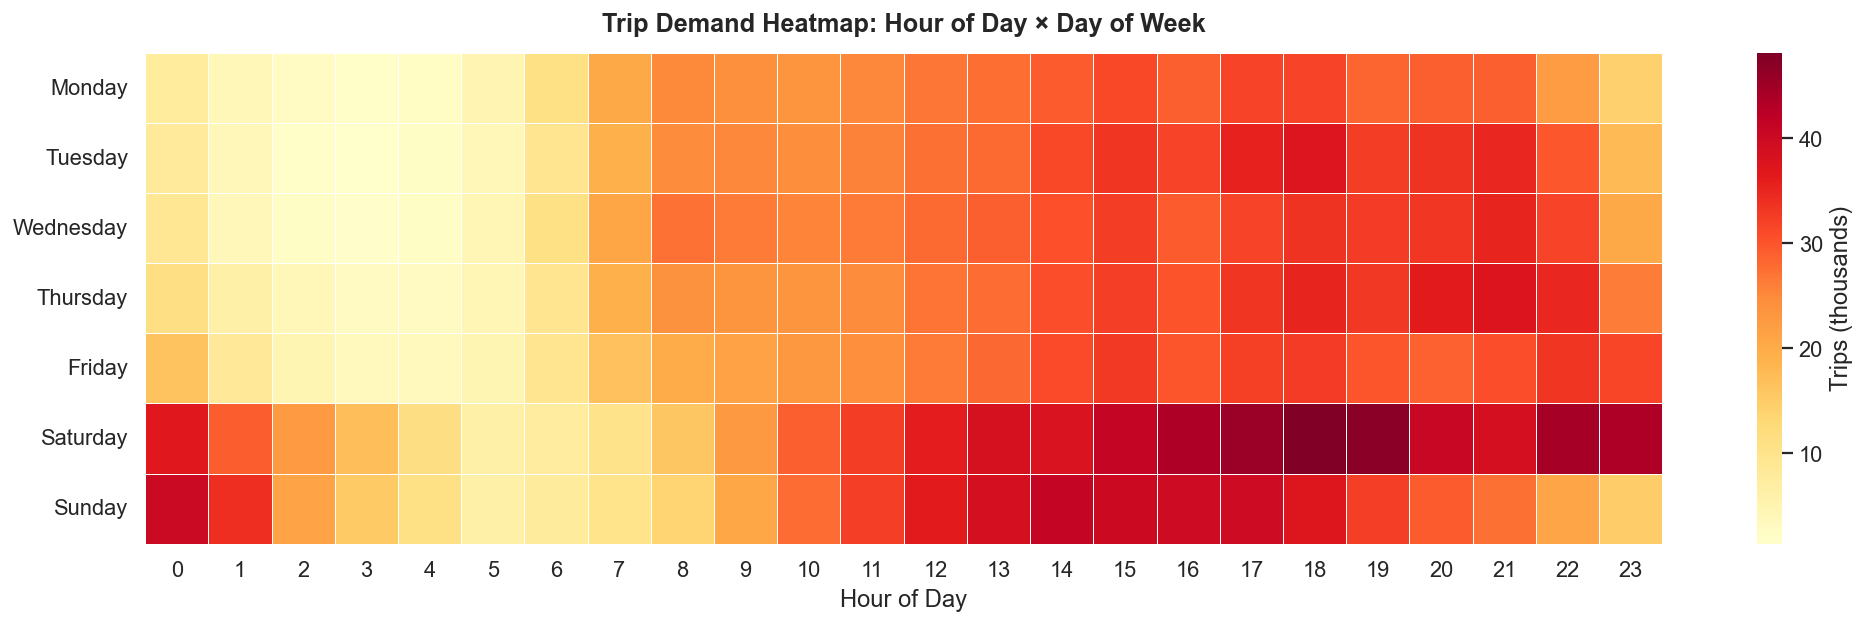

In [7]:
# ── Plot 3: Hour × Day heatmap (the money plot) ────────────────────────────────
# This is the most information-dense view. A heatmap lets us see the full
# demand surface at once — every hour, every day, in a single glance.
# pivot_table reshapes the data: rows = days, columns = hours, values = trip count.

heatmap_data = (
    layer1_df.groupby(["day_of_week", "hour"])
    .size()
    .reset_index(name="trips")
    .pivot_table(index="day_of_week", columns="hour", values="trips")
    .reindex(DAY_ORDER)   # enforce Mon → Sun ordering
)

fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(
    heatmap_data / 1_000,
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="white",
    annot=False,
    fmt=".0f",
    cbar_kws={"label": "Trips (thousands)"},
    ax=ax
)

ax.set_title("Trip Demand Heatmap: Hour of Day × Day of Week", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("")
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
# plt.savefig("plots/03_demand_heatmap.png", bbox_inches="tight")
plt.show()

## What does a typical trip look like?

In [8]:
# ── Summary statistics ─────────────────────────────────────────────────────────
# We cap the display at the 99th percentile to exclude extreme outliers from
# the table, while still noting their existence.

trip_cols = ["trip_distance", "trip_duration_sec", "fare_amount", "total_amount", "tip_amount"]

# Add duration in minutes for readability
revenue_df = revenue_df.copy()
revenue_df["trip_duration_min"] = revenue_df["trip_duration_sec"] / 60

summary_cols = ["trip_distance", "trip_duration_min", "fare_amount", "total_amount"]

stats = revenue_df[summary_cols].agg(["median", "mean", lambda x: x.quantile(0.95)]).round(2)
stats.index = ["Median", "Mean", "95th Percentile"]
stats.columns = ["Distance (mi)", "Duration (min)", "Fare ($)", "Total ($)"]
print("Trip Profile — Key Statistics")
print("(Refunds excluded | Revenue layer)\n")
stats

Trip Profile — Key Statistics
(Refunds excluded | Revenue layer)



,Distance (mi),Duration (min),Fare ($),Total ($)
Median,1.93,14.53,13.50,21.06
Mean,3.55,18.33,18.15,26.93
95th Percentile,13.17,46.12,56.50,76.75


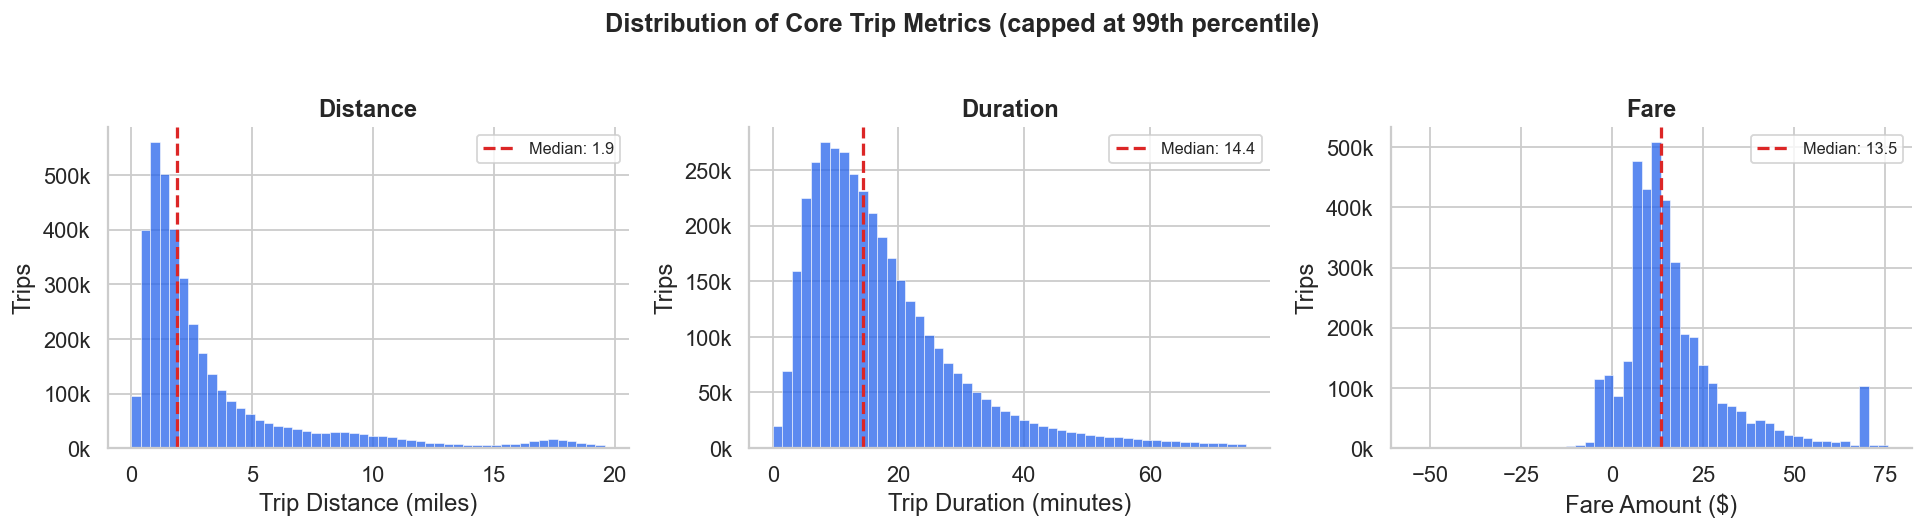

In [9]:
# ── Plot 4: Distribution triptych ─────────────────────────────────────────────
# We cap each variable at the 99th percentile for visualization only.
# Plotting the full range would compress all the data into a tiny sliver
# on the left because of extreme outliers.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Distribution of Core Trip Metrics (capped at 99th percentile)",
             fontsize=14, fontweight="bold", y=1.02)

metrics = [
    ("trip_distance",    "Trip Distance (miles)",   "Distance"),
    ("trip_duration_min","Trip Duration (minutes)",  "Duration"),
    ("fare_amount",      "Fare Amount ($)",           "Fare"),
]

for ax, (col, xlabel, title) in zip(axes, metrics):
    cap = revenue_df[col].quantile(0.99)
    data = revenue_df[revenue_df[col] <= cap][col]

    sns.histplot(data, bins=50, ax=ax, color=ACCENT, edgecolor="white", linewidth=0.3)

    # Median line
    median_val = data.median()
    ax.axvline(median_val, color="#DC2626", linewidth=1.8, linestyle="--", label=f"Median: {median_val:.1f}")
    ax.legend(fontsize=9)

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Trips")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.tight_layout()
# plt.savefig("plots/04_trip_distributions.png", bbox_inches="tight")
plt.show()

## Which vendor generates the most revenue, and why?

In [10]:
# ── Vendor revenue decomposition ───────────────────────────────────────────────
# We use revenue_df (refunds excluded) for fair financial comparison.
# agg() lets us compute multiple statistics in one groupby call.

vendor_stats = (
    revenue_df.groupby("vendor_name")
    .agg(
        trips        = ("total_amount", "count"),
        total_rev    = ("total_amount", "sum"),
        avg_fare     = ("fare_amount",  "median"),
        avg_total    = ("total_amount", "median"),
        avg_tip      = ("tip_amount",   "median"),
        avg_distance = ("trip_distance","median"),
    )
    .reset_index()
    .sort_values("total_rev", ascending=False)
)

vendor_stats["rev_share_pct"]  = (vendor_stats["total_rev"]  / vendor_stats["total_rev"].sum() * 100).round(1)
vendor_stats["trip_share_pct"] = (vendor_stats["trips"]       / vendor_stats["trips"].sum()    * 100).round(1)
vendor_stats["total_rev_M"]    = (vendor_stats["total_rev"]   / 1_000_000).round(1)

print("Vendor Performance Summary")
vendor_stats[["vendor_name", "trips", "trip_share_pct", "total_rev_M", "rev_share_pct", "avg_fare", "avg_tip", "avg_distance"]]

Vendor Performance Summary


,vendor_name,trips,trip_share_pct,total_rev_M,rev_share_pct,avg_fare,avg_tip,avg_distance
1,Curb Mobility,3060971,79.0,81.3,78.0,12.8,2.38,1.92
0,Creative Mobile Technologies,808813,20.9,22.9,21.9,15.6,2.00,2.00
2,Myle Technologies,4224,0.1,0.1,0.1,2.9,0.00,8.65


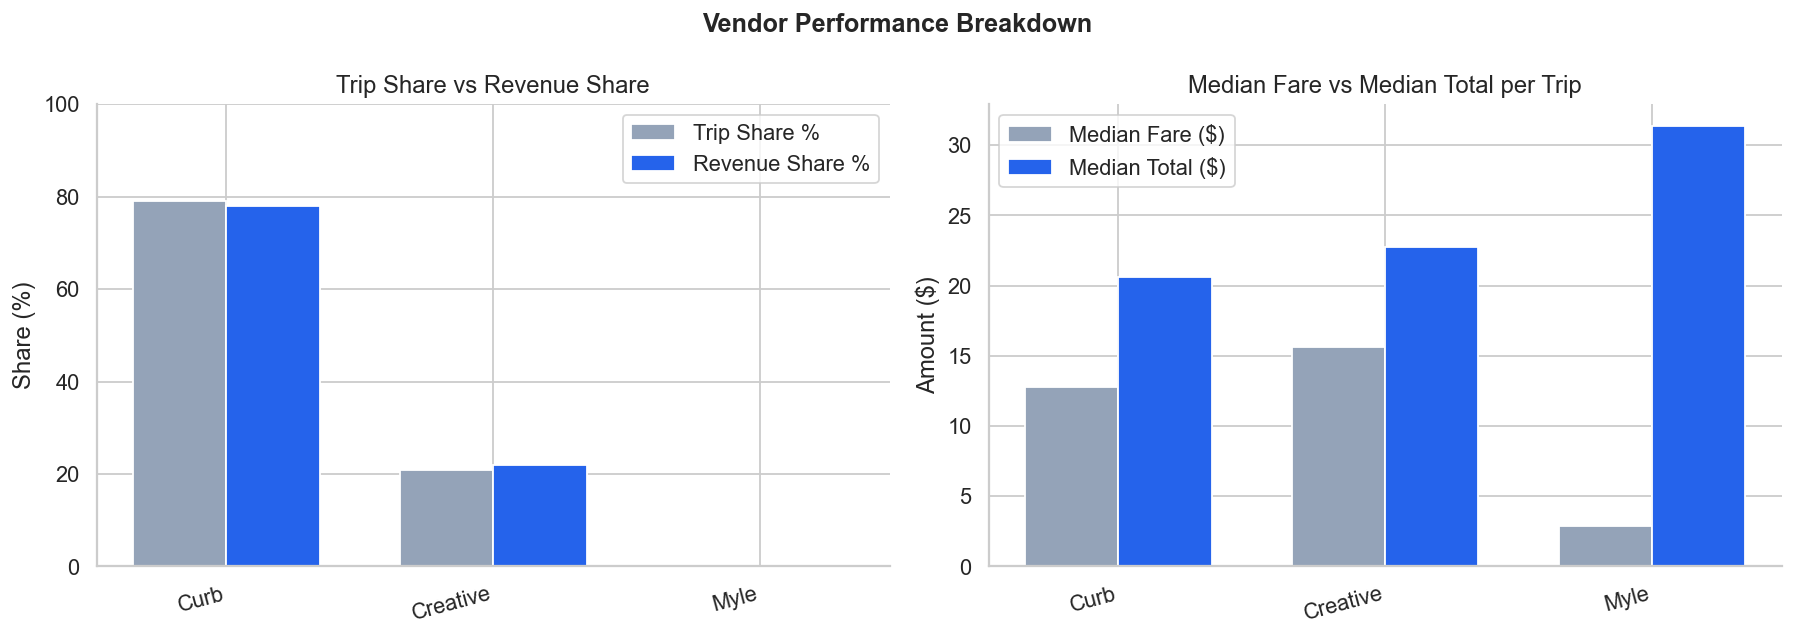

In [11]:
# ── Plot 5: Vendor comparison — trips vs revenue share ─────────────────────────
# Side-by-side bars let us directly compare trip share vs revenue share.
# If both bars are equal, revenue is purely volume-driven.
# If revenue bar > trip bar, that vendor earns more per trip.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Vendor Performance Breakdown", fontsize=14, fontweight="bold")

# Shorten vendor names for labels
short_names = vendor_stats["vendor_name"].str.split().str[0]  # first word only

# Left: Trip share vs Revenue share
x = range(len(vendor_stats))
width = 0.35
bars1 = axes[0].bar([i - width/2 for i in x], vendor_stats["trip_share_pct"],
                    width, label="Trip Share %", color=GRAY)
bars2 = axes[0].bar([i + width/2 for i in x], vendor_stats["rev_share_pct"],
                    width, label="Revenue Share %", color=ACCENT)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(short_names, rotation=15, ha="right")
axes[0].set_ylabel("Share (%)")
axes[0].set_title("Trip Share vs Revenue Share")
axes[0].legend()
axes[0].set_ylim(0, 100)

# Right: Median fare and total amount per vendor
x2 = range(len(vendor_stats))
axes[1].bar([i - width/2 for i in x2], vendor_stats["avg_fare"],
            width, label="Median Fare ($)", color=GRAY)
axes[1].bar([i + width/2 for i in x2], vendor_stats["avg_total"],
            width, label="Median Total ($)", color=ACCENT)
axes[1].set_xticks(list(x2))
axes[1].set_xticklabels(short_names, rotation=15, ha="right")
axes[1].set_ylabel("Amount ($)")
axes[1].set_title("Median Fare vs Median Total per Trip")
axes[1].legend()

plt.tight_layout()
# plt.savefig("plots/05_vendor_revenue.png", bbox_inches="tight")
plt.show()

## How does payment method affect tipping behaviour?

In [12]:
# ── Credit card trips only for tip analysis ────────────────────────────────────
# payment_type == 1 is Credit Card (per data dictionary)
# We also require fare_amount > 0 to avoid division by zero in tip_rate.

cc_df = revenue_df[
    (revenue_df["payment_type"] == 1) &
    (revenue_df["fare_amount"]  > 0)
].copy()

cc_df["tip_rate"] = cc_df["tip_amount"] / cc_df["fare_amount"]

# Add hour column if not already present
cc_df["hour"] = cc_df["tpep_pickup_datetime"].dt.hour

print(f"Credit card trips (tip analysis base): {len(cc_df):,}")
print(f"Median tip rate: {cc_df['tip_rate'].median():.1%}")
print(f"Mean tip rate:   {cc_df['tip_rate'].mean():.1%}")

Credit card trips (tip analysis base): 2,625,772
Median tip rate: 26.1%
Mean tip rate:   24.6%


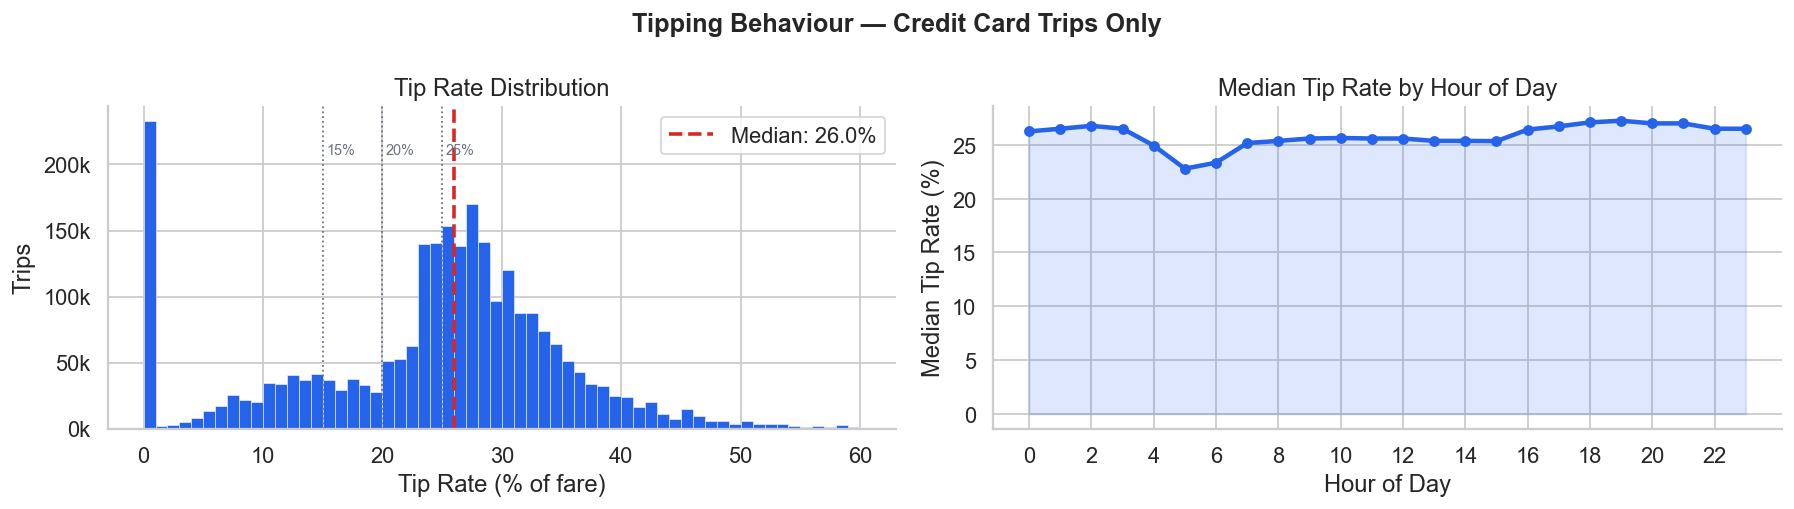

In [13]:
# ── Plot 6: Tip rate distribution + tip rate by hour ─────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Tipping Behaviour — Credit Card Trips Only", fontsize=14, fontweight="bold")

# Left: Tip rate distribution (cap at 60% to exclude extreme outliers)
tip_cap = 0.60
tip_data = cc_df[cc_df["tip_rate"] <= tip_cap]["tip_rate"]

axes[0].hist(tip_data * 100, bins=60, color=ACCENT, edgecolor="white", linewidth=0.3)
axes[0].axvline(tip_data.median() * 100, color="#DC2626", linestyle="--", linewidth=2,
                label=f"Median: {tip_data.median():.1%}")
# Highlight common tip thresholds
for pct, label in [(15, "15%"), (20, "20%"), (25, "25%")]:
    axes[0].axvline(pct, color="#6B7280", linestyle=":", linewidth=1)
    axes[0].text(pct + 0.3, axes[0].get_ylim()[1] * 0.85, label, fontsize=8, color="#6B7280")
axes[0].set_xlabel("Tip Rate (% of fare)")
axes[0].set_ylabel("Trips")
axes[0].set_title("Tip Rate Distribution")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

# Right: Median tip rate by hour
tip_by_hour = cc_df.groupby("hour")["tip_rate"].median().reset_index()
axes[1].plot(tip_by_hour["hour"], tip_by_hour["tip_rate"] * 100,
             color=ACCENT, linewidth=2.5, marker="o", markersize=5)
axes[1].fill_between(tip_by_hour["hour"], tip_by_hour["tip_rate"] * 100,
                     alpha=0.15, color=ACCENT)
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Median Tip Rate (%)")
axes[1].set_title("Median Tip Rate by Hour of Day")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
# plt.savefig("plots/06_tip_behaviour.png", bbox_inches="tight")
plt.show()

## How do airport trips differ from regular trips?

In [14]:
# ── Tag airport trips ──────────────────────────────────────────────────────────
# A trip is airport-related if:
#   - RatecodeID is 2 (JFK flat rate) or 3 (Newark), OR
#   - Airport_fee > 0 (pickup surcharge at JFK or LGA)

layer2_df = layer2_df.copy()
layer2_df["is_airport"] = (
    layer2_df["RatecodeID"].isin([2.0, 3.0]) |
    (layer2_df["Airport_fee"] > 0)
)

# Add tip_rate for comparison
layer2_df["tip_rate"] = np.where(
    (layer2_df["payment_type"] == 1) & (layer2_df["fare_amount"] > 0),
    layer2_df["tip_amount"] / layer2_df["fare_amount"],
    np.nan  # non-credit-card trips → no recorded tip
)

# Add duration in minutes
layer2_df["trip_duration_min"] = layer2_df["trip_duration_sec"] / 60

airport_count = layer2_df["is_airport"].sum()
total_count   = len(layer2_df)
print(f"Airport trips:     {airport_count:,} ({airport_count/total_count:.1%} of layer 2 trips)")
print(f"Non-airport trips: {total_count - airport_count:,}")

Airport trips:     291,794 (9.5% of layer 2 trips)
Non-airport trips: 2,768,501


In [15]:
# ── Comparison table ───────────────────────────────────────────────────────────

compare_cols = ["fare_amount", "total_amount", "trip_distance", "trip_duration_min", "tip_rate"]

airport_comparison = (
    layer2_df.groupby("is_airport")[compare_cols]
    .median()
    .round(2)
    .rename(index={False: "Non-Airport", True: "Airport"})
    .T
)
airport_comparison["Difference"] = (
    airport_comparison["Airport"] - airport_comparison["Non-Airport"]
).round(2)
airport_comparison["% Difference"] = (
    airport_comparison["Difference"] / airport_comparison["Non-Airport"] * 100
).round(1).astype(str) + "%"

airport_comparison.index = ["Fare ($)", "Total ($)", "Distance (mi)", "Duration (min)", "Tip Rate"]
print("Airport vs Non-Airport Trip Comparison (Medians)")
airport_comparison

Airport vs Non-Airport Trip Comparison (Medians)


is_airport,Non-Airport,Airport,Difference,% Difference
Fare ($),12.80,59.70,46.90,366.4%
Total ($),21.05,80.71,59.66,283.4%
Distance (mi),1.56,12.24,10.68,684.6%
Duration (min),12.53,37.00,24.47,195.3%
Tip Rate,0.26,0.23,-0.03,-11.5%


C:\Users\laran\AppData\Local\Temp\ipykernel_37288\3978018086.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\laran\AppData\Local\Temp\ipykernel_37288\3978018086.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\laran\AppData\Local\Temp\ipykernel_37288\3978018086.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


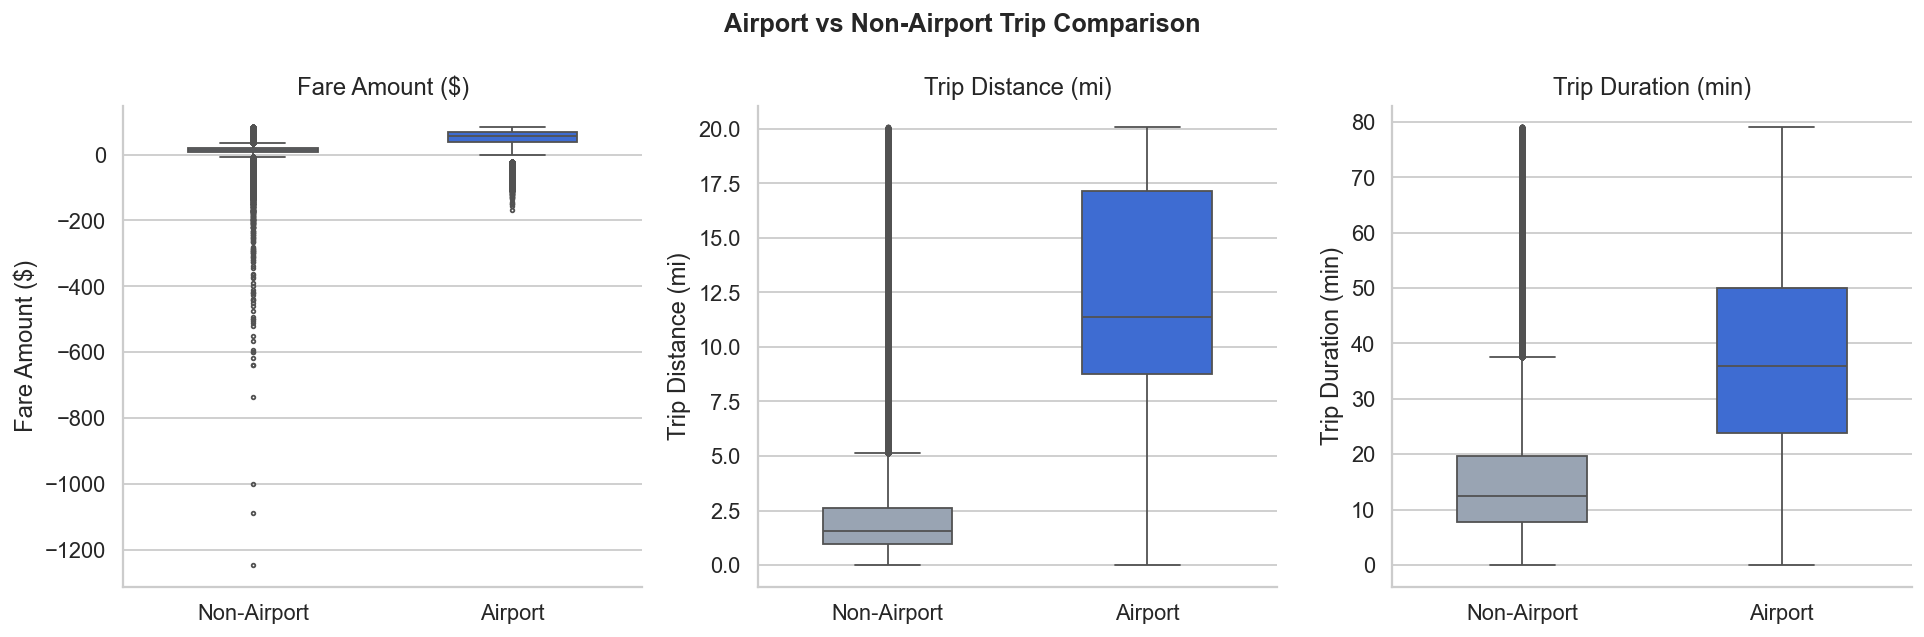

In [16]:
# ── Plot 7: Airport vs Non-Airport — boxplots ──────────────────────────────────
# Boxplots show median + spread + outliers simultaneously — better than a bar
# chart for comparing distributions. We cap each at the 99th percentile.

metrics_to_plot = [
    ("fare_amount",       "Fare Amount ($)"),
    ("trip_distance",     "Trip Distance (mi)"),
    ("trip_duration_min", "Trip Duration (min)"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Airport vs Non-Airport Trip Comparison", fontsize=14, fontweight="bold")

for ax, (col, ylabel) in zip(axes, metrics_to_plot):
    cap = layer2_df[col].quantile(0.99)
    plot_data = layer2_df[layer2_df[col] <= cap].copy()
    plot_data["Trip Type"] = plot_data["is_airport"].map({True: "Airport", False: "Non-Airport"})

    sns.boxplot(
        data=plot_data, x="Trip Type", y=col,
        palette={"Airport": ACCENT, "Non-Airport": GRAY},
        width=0.5, fliersize=2, ax=ax
    )
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

plt.tight_layout()
# plt.savefig("plots/07_airport_comparison.png", bbox_inches="tight")
plt.show()

## Are there remaining data quality signals worth flagging?

In [17]:
# ── Zero-distance trips ────────────────────────────────────────────────────────
# These passed our speed filter (speed > 1 mph) which means they have some
# trip_duration_sec > 0 but trip_distance == 0. GPS odometer failure?

zero_dist = revenue_df[revenue_df["trip_distance"] == 0]
print(f"Zero-distance trips: {len(zero_dist):,} ({len(zero_dist)/len(revenue_df):.2%} of revenue trips)")
print("\nFare distribution for zero-distance trips:")
zero_dist[["fare_amount", "total_amount", "trip_duration_sec"]].describe().round(2)

Zero-distance trips: 0 (0.00% of revenue trips)

Fare distribution for zero-distance trips:


,fare_amount,total_amount,trip_duration_sec
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


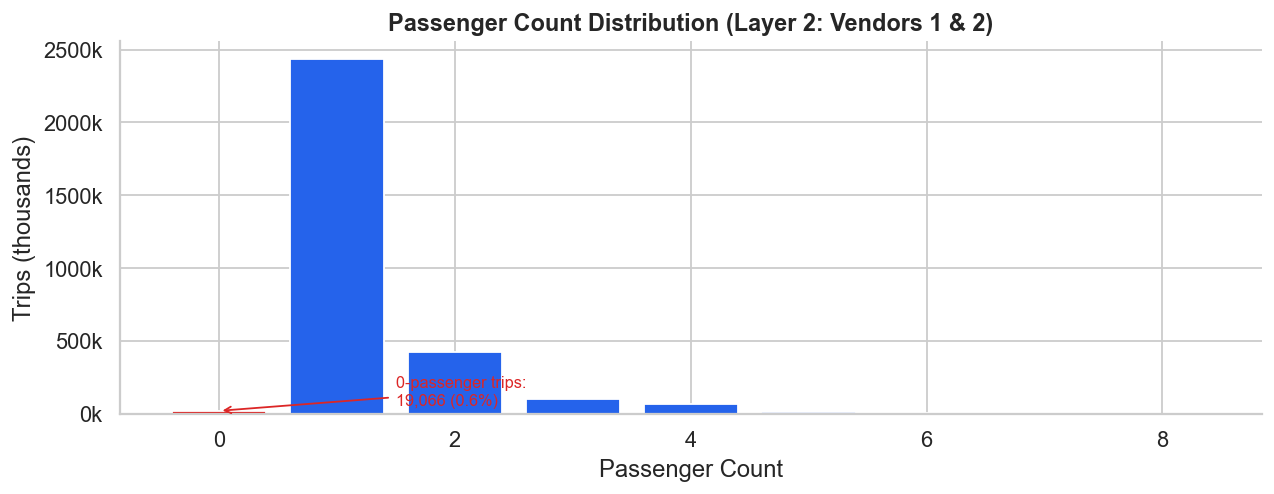

In [18]:
# ── Passenger count distribution ───────────────────────────────────────────────
# 0 passengers is technically impossible — but it appears in the data.
# This could be: driver testing the meter, automated dispatch logging, or a
# data entry error. We document it; we don't silently drop it.

pax_dist = (
    layer2_df.groupby("passenger_count")
    .size()
    .reset_index(name="trips")
    .assign(pct=lambda x: (x["trips"] / x["trips"].sum() * 100).round(2))
)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(pax_dist["passenger_count"], pax_dist["trips"] / 1_000,
              color=["#DC2626" if p == 0 else ACCENT for p in pax_dist["passenger_count"]],
              edgecolor="white")
ax.set_xlabel("Passenger Count")
ax.set_ylabel("Trips (thousands)")
ax.set_title("Passenger Count Distribution (Layer 2: Vendors 1 & 2)", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))

# Annotate the 0-passenger bar
zero_pax_count = layer2_df[layer2_df["passenger_count"] == 0].shape[0]
ax.annotate(f"0-passenger trips:\n{zero_pax_count:,} ({zero_pax_count/len(layer2_df):.1%})",
            xy=(0, zero_pax_count / 1_000),
            xytext=(1.5, zero_pax_count / 1_000 * 3),
            arrowprops=dict(arrowstyle="->", color="#DC2626"),
            color="#DC2626", fontsize=9)

plt.tight_layout()
# plt.savefig("plots/08_passenger_distribution.png", bbox_inches="tight")
plt.show()

In [19]:
# ── Total amount reconciliation ────────────────────────────────────────────────
# Does total_amount = sum of all component charges?
# We can check this for vendors 1 & 2 where all fields are present.

check_df = layer2_df.dropna(subset=[
    "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
    "improvement_surcharge", "congestion_surcharge", "Airport_fee", "cbd_congestion_fee"
]).copy()

check_df["calculated_total"] = (
    check_df["fare_amount"]
    + check_df["extra"]
    + check_df["mta_tax"]
    + check_df["tip_amount"]
    + check_df["tolls_amount"]
    + check_df["improvement_surcharge"]
    + check_df["congestion_surcharge"]
    + check_df["Airport_fee"]
    + check_df["cbd_congestion_fee"]
)

check_df["total_discrepancy"] = (check_df["total_amount"] - check_df["calculated_total"]).abs()

print("Discrepancy between total_amount and sum of components:")
print(check_df["total_discrepancy"].describe().round(4))
print(f"\nTrips with discrepancy > $1: {(check_df['total_discrepancy'] > 1).sum():,}")
print(f"Trips with discrepancy > $5: {(check_df['total_discrepancy'] > 5).sum():,}")

Discrepancy between total_amount and sum of components:
count    3.060295e+06
mean     5.652000e-01
std      1.218600e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.000000e+00
Name: total_discrepancy, dtype: float64

Trips with discrepancy > $1: 554,009
Trips with discrepancy > $5: 233
